# KNN Regressor - Solar Wastage
Train and evaluate a KNeighborsRegressor model using features_regression_ready.csv.

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Define file paths (relative to notebooks/training/)
DATA_PATH = Path('../../data/processed/features_regression_ready.csv')  # Input data
MODEL_PATH = Path('../../models/knn_regressor_pipeline.pkl')  # Output model
METRICS_PATH = Path('../../models/knn_regressor_metrics.json')  # Output metrics
RANDOM_STATE = 42  # For reproducibility

In [3]:
# Load and prepare data
df = pd.read_csv(DATA_PATH)
target_col = 'wasted_energy_kwh'  # Target variable to predict

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Define column types for preprocessing
categorical_cols = ['household', 'season', 'district']
numerical_cols = [c for c in X.columns if c not in categorical_cols]
X.head()

,daily_pv_kwh,daily_load_kwh,household,year,month,day,quarter,day_of_week,day_of_year,week_of_year,...,load_rolling_mean_14d,pv_rolling_std_14d,wastage_rolling_mean_14d,pv_rolling_mean_30d,load_rolling_mean_30d,pv_rolling_std_30d,wastage_rolling_mean_30d,district,irradiance,temp
0,0.010838,0.018602,residential1,2015,5,21,2,3,141,21,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,Colombo,5.6695,26.91
1,0.555957,0.214720,residential1,2015,5,22,2,4,142,21,...,0.018602,0.000000,0.0,0.010838,0.018602,0.000000,0.0,Colombo,6.0698,27.17
2,1.382767,0.409031,residential1,2015,5,23,2,5,143,21,...,0.116661,0.385457,0.0,0.283398,0.116661,0.385457,0.0,Colombo,4.5922,27.20
3,2.177085,0.574465,residential1,2015,5,24,2,6,144,21,...,0.214118,0.690768,0.0,0.649854,0.214118,0.690768,0.0,Colombo,6.2059,27.32
4,2.962496,0.684174,residential1,2015,5,25,2,0,145,22,...,0.304204,0.949324,0.0,1.031662,0.304204,0.949324,0.0,Colombo,6.1730,27.30


In [4]:
# Define preprocessing pipelines for different column types
# Categorical: impute missing values with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numerical: impute missing values with median, then standardize
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

In [5]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [6]:
# Create KNN regressor model (default k=5 neighbors)
model = KNeighborsRegressor()

# Build pipeline: preprocessing -> model
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

# Train the model and make predictions
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [7]:
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)            # R-squared (coefficient of determination)
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
rmse = root_mean_squared_error(y_test, y_pred)  # Root Mean Squared Error

# Display results
print('KNeighborsRegressor Results')
print('=' * 50)
print(f'R2:   {r2:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

KNeighborsRegressor Results
R2:   0.9945
MAE:  2.5968
RMSE: 9.3892


In [8]:
# Save metrics and trained model
metrics = {'R2': float(r2), 'MAE': float(mae), 'RMSE': float(rmse)}

# Create models directory if it doesn't exist
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save pipeline (includes preprocessor + model)
joblib.dump(pipeline, MODEL_PATH)

# Save metrics as JSON
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Saved:', MODEL_PATH, METRICS_PATH)

Saved: ..\..\models\knn_regressor_pipeline.pkl ..\..\models\knn_regressor_metrics.json


## Plot: Actual vs Predicted
Visualize model performance by comparing actual wastage values against predictions.

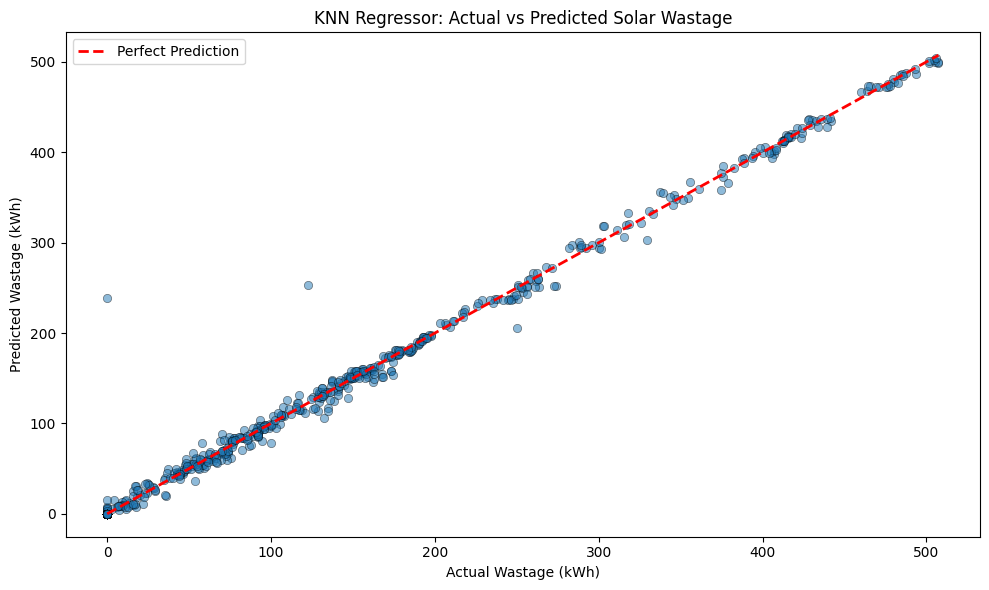

In [9]:
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Wastage (kWh)')
plt.ylabel('Predicted Wastage (kWh)')
plt.title('KNN Regressor: Actual vs Predicted Solar Wastage')
plt.legend()
plt.tight_layout()
plt.savefig('../../results/knn_regressor_predictions.png', dpi=150)
plt.show()

## Prediction Function
A reusable function to predict solar energy wastage from new input data.

In [10]:
def predict_wastage(new_data_dict, model_path=MODEL_PATH):
    """
    Predict solar energy wastage from input features using the trained KNN model.
    
    Parameters:
    -----------
    new_data_dict : dict
        Dictionary containing feature values. Missing features default to 0.
    model_path : Path
        Path to the saved model pipeline.
        
    Returns:
    --------
    float : Predicted wasted energy in kWh (minimum 0.0).
    """
    # Get feature names from training data
    feature_names = X.columns.tolist()
    
    # Initialize all features with default value 0
    row = {name: 0.0 for name in feature_names}
    
    # Update with user-provided values
    for key, value in new_data_dict.items():
        if key in row:
            row[key] = value
    
    # Convert to DataFrame and predict
    input_df = pd.DataFrame([row])
    loaded_pipeline = joblib.load(model_path)
    prediction = loaded_pipeline.predict(input_df)[0]
    
    # Return prediction (wastage cannot be negative)
    return max(0.0, float(prediction))


# Example usage
example_input = {
    'daily_pv_kwh': 5.0, 
    'daily_load_kwh': 3.0, 
    'irradiance': 5.5,
    'temp': 28.0, 
    'district': 'Colombo', 
    'season': 'Southwest_Monsoon', 
    'household': 'residential1'
}
print(f"Example prediction: {predict_wastage(example_input):.4f} kWh")

Example prediction: 0.0000 kWh
